# PS-S06E07: Random Forest

This notebook tackles the [**Playground Series – Season 6, Episode 7: Predicting Student Health Risk**](https://www.kaggle.com/competitions/playground-series-s6e7).

## Introduction

**Random Forest** is an ensembling method based on bagging decision trees. It is diverse from boosting methods (like XGBoost, LightGBM, and CatBoost), making it highly valuable for stacking and ensembling. Even if its standalone score is slightly lower, its differently distributed errors will improve the ensembled models.

The target is a three-class classification (`at-risk`, `unhealthy`, and `fit`) evaluated by **Balanced Accuracy**.

In [1]:
import os
import gc
import sys
import json
import warnings

import numpy as np
import pandas as pd
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, balanced_accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFECV

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e07_feature_engineering import FeatureFactory
from ps_s06e07_model_visualizer import ModelVisualizer
from ps_s06e07_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
setup = ExperimentSetup(
    model_name='Random Forest',
    use_gpu=False,  # sklearn RF is CPU-based
    perform_rfe=False,
    perform_optuna_tuning=False
)

seed = setup.set_seeds()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'health_condition'
target_mapping = {'at-risk': 0, 'unhealthy': 1, 'fit': 2}
inverse_target_mapping = {v: k for k, v in target_mapping.items()}
N_CLASSES = 3

Random seed set to: 10301
Warnings suppressed.


## Read the Datasets

In [3]:
training_df = setup.get_combined_training_data(include_original=False)
train_ids = training_df['id'].copy()
test_df = setup.read_dataset('test')
test_ids = test_df['id'].copy()

TRAINING DATASET

   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy           5.220      70.600 25.660   
1   1          at-risk           5.530      71.300 25.840   
2   2        unhealthy           5.290      75.400 24.540   
3   3        unhealthy           4.700      77.200 23.130   
4   4          at-risk           7.230      73.400 28.440   

   calorie_expenditure  step_count  exercise_duration  water_intake diet_type  \
0            2,174.000   1,326.000             19.800         1.860       veg   
1            1,966.000   9,891.000             49.900         1.260   non-veg   
2            2,688.000  14,216.000             38.100         1.600       veg   
3            2,630.000   7,174.000             59.900         2.020       veg   
4            2,560.000   6,584.000             46.000         2.250       veg   

  stress_level sleep_quality physical_activity_level smoking_alcohol  gender  \
0         high       average               seden

## Feature Engineering

In [4]:
fe_strategies = [
    'encoding',
    'sleep_stress',
    'activity_energy',
    'bmi_features',
    'risk_score',
    'missing_flags',
]

y = training_df[TARGET].map(target_mapping).astype(int)

feature_engineer = FeatureFactory(
    strategies=fe_strategies,
    target=TARGET,
    seed=seed
)

X_full = feature_engineer.fit_transform(training_df)
X_test_raw = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')
X_test = X_test_raw.copy()

In [5]:
def fit_nn_encoders(X_train: pd.DataFrame, X_ref: pd.DataFrame, cat_cols: list):
    X_all = pd.concat([X_train[cat_cols], X_ref[cat_cols]], axis=0, ignore_index=True)
    cat_maps = {}
    cat_dims = []
    for c in cat_cols:
        s = X_all[c].astype(str).fillna("__nan__")
        uniq = pd.Index(s.unique())
        cat_maps[c] = {k: i for i, k in enumerate(uniq)}
        cat_dims.append(len(uniq))
    num_cols = [c for c in X_train.columns if c not in cat_cols]
    return {"cat_cols": cat_cols, "num_cols": num_cols, "cat_maps": cat_maps, "cat_dims": cat_dims}

def transform_with_encoders(X: pd.DataFrame, fitted):
    cat_cols = fitted["cat_cols"]
    num_cols = fitted["num_cols"]
    cat_maps = fitted["cat_maps"]
    X_num = X[num_cols].to_numpy(dtype=np.float32)
    X_cat = np.zeros((len(X), len(cat_cols)), dtype=np.int64)
    for j, c in enumerate(cat_cols):
        m = cat_maps[c]
        s = X[c].astype(str).fillna("__nan__")
        X_cat[:, j] = s.map(lambda v: m.get(v, 0)).to_numpy(dtype=np.int64)
    return X_num, X_cat

## Optional Recursive Feature Elimination
If `perform_rfe` is True in setup, Recursive Feature Elimination with Cross-Validation (RFECV) is performed on a numeric-encoded snapshot of the feature-engineered training set. It iteratively removes the weakest feature and re-scores until the optimal subset is found. The selected feature names are then applied per-fold during training to prevent leakage.

In [6]:
# Prep clean numeric matrices for RFE/Optuna
cat_features = feature_engineer.get_cat_features(X)
fitted_encoders = fit_nn_encoders(X, X_test, cat_features)

X_num_np, X_cat_np = transform_with_encoders(X, fitted_encoders)
X_test_num_np, X_test_cat_np = transform_with_encoders(X_test, fitted_encoders)

# Impute numerics
imputer = SimpleImputer(strategy='median')
X_num_np = imputer.fit_transform(X_num_np)
X_test_num_np = imputer.transform(X_test_num_np)

# Concatenate numeric + categorical integer codes for scikit-learn
X_numeric_all = np.hstack([X_num_np, X_cat_np])
X_test_numeric_all = np.hstack([X_test_num_np, X_test_cat_np])

feature_names = fitted_encoders["num_cols"] + fitted_encoders["cat_cols"]
X_rfe_df = pd.DataFrame(X_numeric_all, columns=feature_names)

rfe_filename = 'selected_features_rf.json'
optimal_cols = X_rfe_df.columns

if setup.perform_rfe():
    print('Running RFECV for Random Forest (this will take a few minutes)...')
    clf_fs = RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        class_weight='balanced',
        random_state=seed,
        n_jobs=-1
    )
    
    rfecv = RFECV(
        estimator=clf_fs,
        step=3,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=seed),
        scoring='balanced_accuracy',
        min_features_to_select=15,
        n_jobs=1,
        verbose=1
    )
    
    rfecv.fit(X_numeric_all, y)
    print(f'Optimal number of features: {rfecv.n_features_}')
    
    optimal_cols = X_rfe_df.columns[rfecv.support_]
    setup.save_rfe(rfe_filename, optimal_cols)
else:
    optimal_cols = setup.load_rfe(rfe_filename, X_rfe_df)
    if len(optimal_cols) == 0:
        print('\nUsing all features')
        optimal_cols = X_rfe_df.columns

print('\nOptimal Features Count:', len(optimal_cols))

# Subset the processed matrices to the selected features
selected_indices = [feature_names.index(c) for c in optimal_cols]
X_final_np = X_numeric_all[:, selected_indices]
X_test_final_np = X_test_numeric_all[:, selected_indices]

RFE file 'selected_features_rf.json' not found — using all 38 columns.

Optimal Features Count: 38


## Optional Optuna Training

If `perform_optuna_tuning` is `True` in `setup`, an Optuna study maximizes Balanced Accuracy over the full 5-fold CV loop. Otherwise, a previously derived best-params dict is used directly.

In [7]:
optuna_filename = 'optuna_params_rf.json'

if setup.perform_optuna_tuning():
    print('Starting Optuna Hyperparameter Optimization...')
    
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            'max_depth': trial.suggest_int('max_depth', 8, 25),
            'min_samples_split': trial.suggest_int('min_samples_split', 10, 100),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            'class_weight': 'balanced',
            'random_state': seed,
            'n_jobs': -1
        }
        
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
        scores = []
        
        for train_idx, val_idx in cv.split(X_final_np, y):
            X_tr, y_tr = X_final_np[train_idx], y.iloc[train_idx]
            X_val, y_val = X_final_np[val_idx], y.iloc[val_idx]
            
            clf = RandomForestClassifier(**params)
            clf.fit(X_tr, y_tr)
            preds = clf.predict(X_val)
            scores.append(balanced_accuracy_score(y_val, preds))
            
        return np.mean(scores)
        
    study = optuna.create_study(direction='maximize', study_name='rf_tuning')
    study.optimize(objective, n_trials=30)
    
    print(f'Best Trial Score: {study.best_value:.6f}')
    best_params = study.best_params
    setup.save_optuna_params(optuna_filename, best_params)
else:
    best_params = setup.load_optuna_params(optuna_filename)
    if not best_params:
        print('Loaded baseline parameters')
        best_params = {
            'n_estimators': 200,
            'max_depth': 15,
            'min_samples_split': 20,
            'min_samples_leaf': 10,
            'max_features': 'sqrt'
        }

Optuna file 'optuna_params_rf.json' not found — returning empty dict.
Loaded baseline parameters


## Model Training

In [8]:
print('Starting 5-Fold Stratified Cross-Validation...')

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

oof_probs = np.zeros((len(training_df), N_CLASSES), dtype=np.float32)
test_probs = np.zeros((len(test_df), N_CLASSES), dtype=np.float32)
scores = []
models = []

comp_mask = training_df['is_original'] == False
comp_idx = np.where(comp_mask)[0]

for fold, (rel_train_idx, rel_val_idx) in enumerate(skf.split(comp_idx, y[comp_idx]), 1):
    train_idx = np.concatenate([comp_idx[rel_train_idx], np.where(~comp_mask)[0]])
    val_idx = comp_idx[rel_val_idx]
    
    print(f'\n=== Fold {fold}/{n_folds} ===')
    
    X_tr, y_tr = X_final_np[train_idx], y.iloc[train_idx]
    X_val, y_val = X_final_np[val_idx], y.iloc[val_idx]
    
    params = {
        **best_params,
        'class_weight': 'balanced',
        'random_state': seed + fold,
        'n_jobs': -1
    }
    
    clf = RandomForestClassifier(**params)
    clf.fit(X_tr, y_tr)
    
    # Predict probabilities
    val_probs = clf.predict_proba(X_val)
    oof_probs[val_idx] = val_probs
    
    # Test prediction contribution
    test_probs += clf.predict_proba(X_test_final_np) / n_folds
    
    fold_preds = np.argmax(val_probs, axis=1)
    fold_score = balanced_accuracy_score(y_val, fold_preds)
    scores.append(fold_score)
    models.append(clf)
    print(f'  Fold {fold} Balanced Accuracy: {fold_score:.6f}')

overall_score = balanced_accuracy_score(y[comp_mask], np.argmax(oof_probs[comp_mask], axis=1))
print(f'\nOverall OOF Balanced Accuracy: {overall_score:.6f}')

Starting 5-Fold Stratified Cross-Validation...

=== Fold 1/5 ===
  Fold 1 Balanced Accuracy: 0.949914

=== Fold 2/5 ===
  Fold 2 Balanced Accuracy: 0.948922

=== Fold 3/5 ===
  Fold 3 Balanced Accuracy: 0.949844

=== Fold 4/5 ===
  Fold 4 Balanced Accuracy: 0.948629

=== Fold 5/5 ===
  Fold 5 Balanced Accuracy: 0.946594

Overall OOF Balanced Accuracy: 0.948781


### Confusion Matrix
A normalized confusion matrix across the three target health classes.
* **Diagonal:** Correct classifications for each class. All three should be high.
* **at-risk column (0):** at-risk cases represent students with severe health risk behaviors; off-diagonal entries here are the most critical failures to monitor.
* **unhealthy row (1):** unhealthy cases represent moderate risks; off-diagonal values between unhealthy and at-risk are common due to overlapping behavior metrics.

Normalized confusion matrix


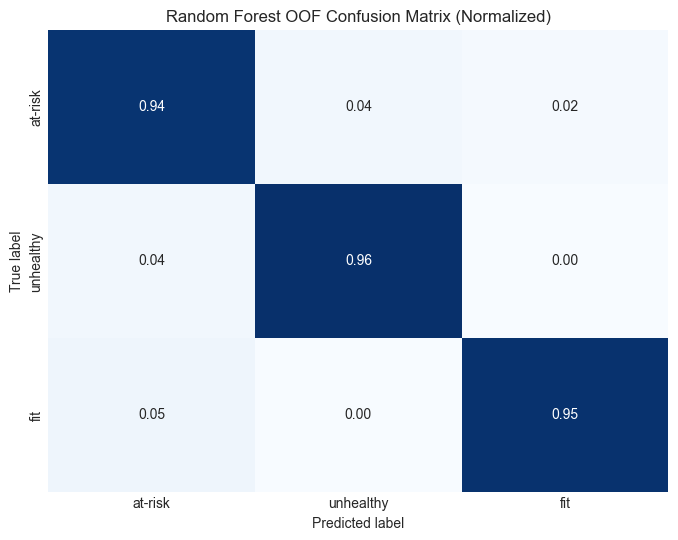

In [9]:
mviz = ModelVisualizer(model_name='Random Forest')

mviz.plot_confusion_matrix(
    y_true=y[comp_mask],
    y_pred=np.argmax(oof_probs[comp_mask], axis=1),
    classes=['at-risk', 'unhealthy', 'fit'],
    normalize=True,
    title='Random Forest OOF Confusion Matrix (Normalized)'
)


### Distribution Mismatch
Overlays the distribution of true class labels against OOF predicted labels (integer-encoded: at-risk=0, unhealthy=1, fit=2). A large divergence on one class suggests the model is systematically misclassifying that health condition.

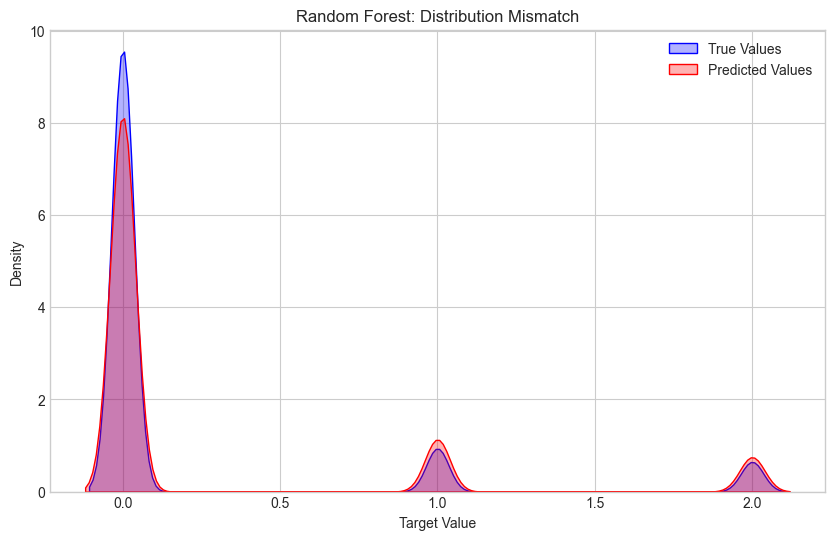

In [10]:
mviz.plot_distribution_mismatch(
    y_true=y[comp_mask],
    y_preds=np.argmax(oof_probs[comp_mask], axis=1)
)

## Prepare Submission

The competition requires the hard predicted class label (`at-risk`, `unhealthy`, and `fit`) for each row in the test set. We derive predictions by taking the argmax of the averaged test probabilities and mapping back to the original string labels.

In [11]:
submission_df = setup.read_dataset('submission')

numeric_preds = np.argmax(test_probs, axis=1)

# Map numeric predictions back to string class labels
pred_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[pred_col] = pd.Series(numeric_preds).map(inverse_target_mapping)

print('SAMPLE SUBMISSION')
display(submission_df.head(20))

SAMPLE SUBMISSION


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
5,690093,fit
6,690094,at-risk
7,690095,at-risk
8,690096,at-risk
9,690097,at-risk


## Save OOF and Test Probabilities

Out-of-fold (OOF) and averaged test-set probabilities are saved for downstream ensembling (blending or stacking).

For this three-class task we save the full probability distribution across , , and  rather than just the argmax labels. Raw probabilities are essential for:

- **Weighted Blending**: Averaging confidence scores across XGBoost, LightGBM, and CatBoost models.
- **Stacking**: Using these probabilities as meta-features for a secondary model.
- **Calibration Analysis**: Verifying that predicted confidence aligns with actual class frequencies.

In [12]:
# Save predictions
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

prob_cols = ['prob_at_risk', 'prob_unhealthy', 'prob_fit']
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)
oof_out = pd.concat([
    pd.DataFrame({'id': train_ids.values, 'target': y.values}),
    oof_prob_df
], axis=1)
# Only keep competition rows (original data has no CV folds/predictions)
oof_out = oof_out[comp_mask]
oof_out.to_csv(f'{output_dir}/rf_oof_probs.csv', index=False)

test_prob_df = pd.concat([
    pd.DataFrame({'id': test_ids.values}),
    pd.DataFrame(test_probs, columns=prob_cols)
], axis=1)
test_prob_df.to_csv(f'{output_dir}/rf_test_probs.csv', index=False)

print('Saved Random Forest probabilities successfully for ensembling!')

Saved Random Forest probabilities successfully for ensembling!
